# Activation Foil Analysis: FLiBe 1L BABY Run #1

This notebook processes the calibration data from HPGe detectors to energy calibrate the detectors and determine total detector efficiencies. Then, NaI measurements of activation foils irradiated during the run with a D-T neutron (14.1 MeV) generator are used to determine the average neutron rate during the run. 

## Obtaining the Data
First, the NaI detector measurement data is obtained from Zenodo and extracted

In [1]:
# parameters

## keep this if statement for ci and process workflows
if 'download_from_raw' not in globals() and 'download_from_raw' not in locals():
    download_from_raw = True

In [2]:
import numpy as np
from datetime import datetime
import json
from libra_toolbox.neutron_detection.activation_foils import compass
from matplotlib import pyplot as plt

In [3]:
from process_foil_data import get_data

detector_type = "HPGe"
check_source_measurements, background_meas, foil_measurements = get_data(download_from_raw=download_from_raw,
                                                                         h5_filename="activation_data.h5",
                                                                         detector_type=detector_type)

Available detector types:  ['HPGe']
Read in properties of Zirconium Packet #3 foil
Read in properties of Zirconium Packet #4 foil
Directory already exists: ../../data/neutron_detection/activation_foils/260310_1L_FLiBe_run2/DAQ
Processing Ba133 Count 1...
Processing Ba133 Count 2...
Processing Co60 Count 1...
Processing Co60 Count 2...
Processing Cs137 Count 1...
Processing Cs137 Count 2...
Processing Na22 Count 1...
Processing Na22 Count 2...
Processing background...
Processing Zirconium Packet #3 Count 1...
Processing Zirconium Packet #3 Count 2...
Processing Zirconium Packet #4 Count 1...
Processing Zirconium Packet #4 Count 2...
Saving processed measurements to h5 file for future use...
 ../../data/neutron_detection/activation_foils HPGe_activation_data.h5
Saving measurements to ../../data/neutron_detection/activation_foils/HPGe_activation_data.h5...


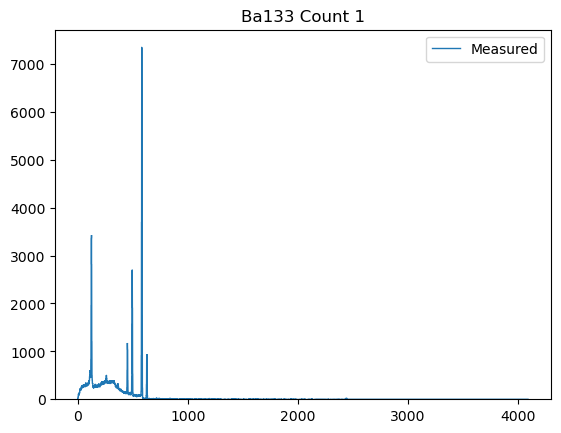

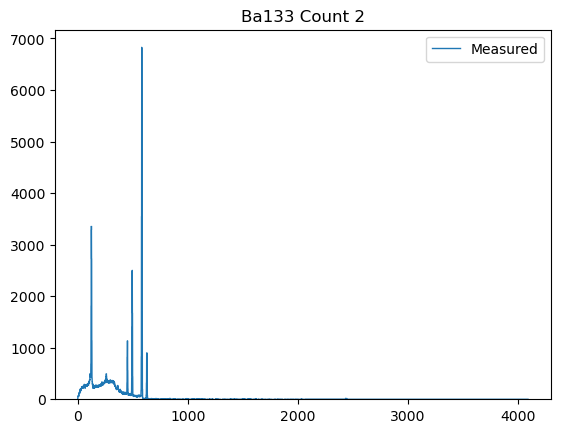

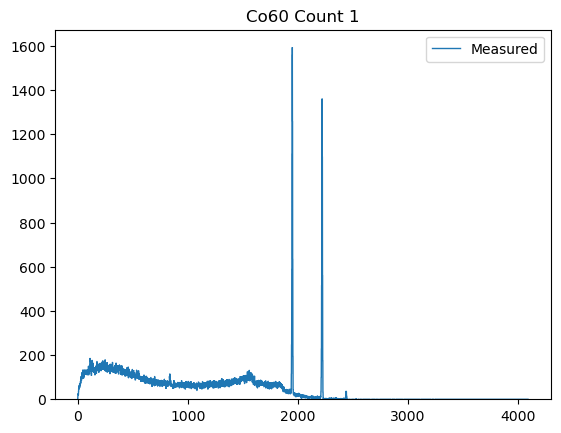

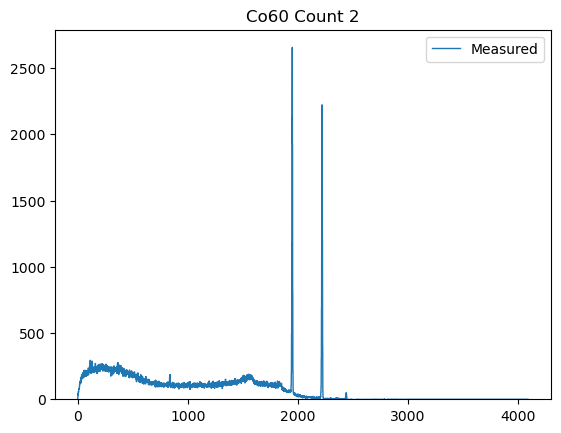

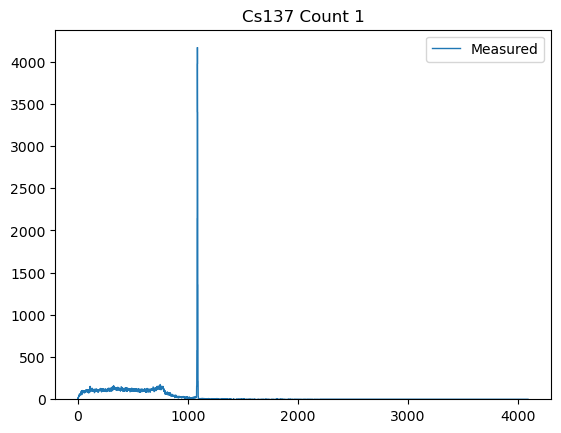

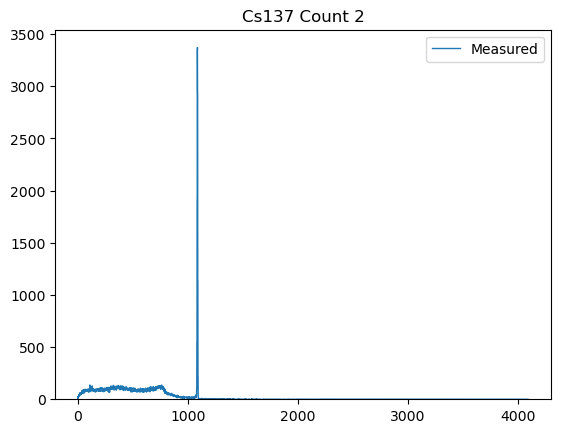

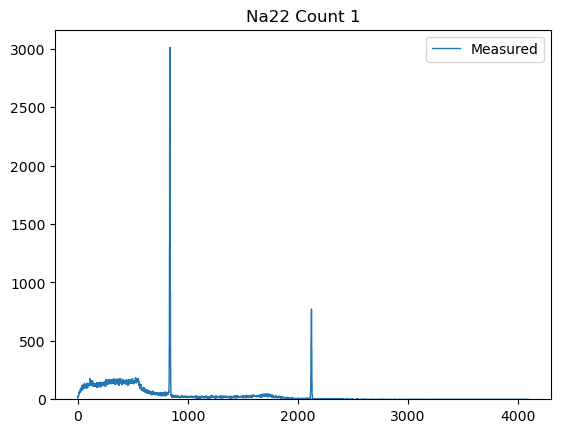

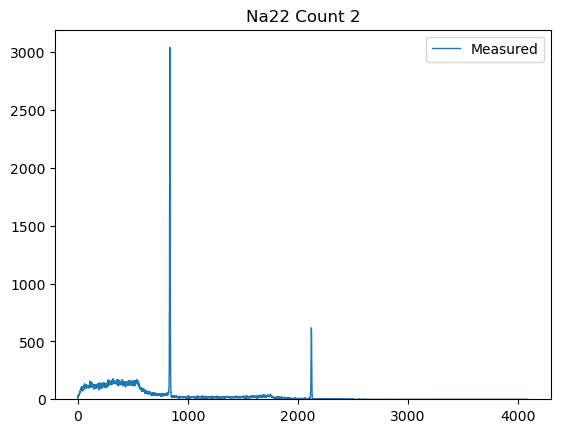

In [ ]:
for name, measurement in check_source_measurements.items():
    fig, ax = plt.subplots()
    det = measurement.get_detector(0)
    hist, xvals = det.get_energy_hist()
    ax.stairs(hist, xvals, label=f'Measured')
    ax.legend()
    ax.set_title(name)
    

## Energy Calibration

Using gamma check sources like Co-60 and Cs-137, the characteristic photon peaks from these sources are used to convert the digitizer channel bins into energy (keV) bins

In [6]:
calibration_coeffs = {}
print(check_source_measurements)
channel_nb = check_source_measurements["Ba133 Count 1"].detectors[0].channel_nb

na22_hist, bins = check_source_measurements["Na22 Count 1"].detectors[0].get_energy_hist()
peak_kwargs = {'Na22': {'start_index': 500,
                        'prominence': na22_hist[500:].max() * 0.2}}
calibration_channels, calibration_energies = compass.get_calibration_data(
    check_source_measurements.values(),
    background_measurement=background_meas,
    channel_nb=channel_nb,
    peak_kwargs=peak_kwargs,
)

coeff = np.polyfit(calibration_channels, calibration_energies, 1)
calibration_coeffs[channel_nb] = coeff

xs = np.linspace(
    calibration_channels[0],
    calibration_channels[-1],
)
plt.plot(
    xs,
    np.polyval(coeff, xs),
    label=f"Ch {channel_nb} fit",
)
plt.scatter(
    calibration_channels,
    calibration_energies,
    label=f"Ch {channel_nb} data",
    alpha=0.5,
)
plt.xlabel("Channel number")
plt.ylabel("Energy (keV)")
plt.legend()
plt.show()

{'Ba133 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x17f76f6b0>, 'Ba133 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x1880652e0>, 'Co60 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x18b9a9130>, 'Co60 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x18af22900>, 'Cs137 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x18bbb6b70>, 'Cs137 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x18c0818b0>, 'Na22 Count 1': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x18c0a3da0>, 'Na22 Count 2': <libra_toolbox.neutron_detection.activation_foils.compass.CheckSourceMeasurement object at 0x18c0b18b0>}


TypeError: unhashable type: 'Nuclide'

## Detector Efficiency

Using these same check-sources, each with a known activity, an efficiency curve for each detector is calculated. 

Two types of efficiency curves are shown: 
1. Exponent of sum of logarithms (used in https://doi.org/10.2172/1524045): $ y = \exp(\sum_{i=0}^n a_n \log(E)^i) $

2. Polynomial fit (3rd order): $ y = \sum_{i=0}^n a_n E^i $

**Only the polynomal fit is currently implemented in libra-toolbox, so that is the curve that will be used to calculate the efficiency of the detectors at measuring the activity of the activation foil peaks.**

In [ ]:
for name, measurement in check_source_measurements.items():
    for detector in measurement.detectors:
        dead_time_fraction = 1 - detector.live_count_time / detector.real_count_time
        print(f"{name} Ch {detector.channel_nb} \n\t Live time: {detector.live_count_time} s \n\t Real time: {detector.real_count_time} s")
        print(f"\t Dead time fraction: {dead_time_fraction:.2%}")

Ba133 Count 1 Ch 0 
	 Live time: 215.615 s 
	 Real time: 723.787 s
	 Dead time fraction: 70.21%
Ba133 Count 2 Ch 0 
	 Live time: 281.445 s 
	 Real time: 979.895 s
	 Dead time fraction: 71.28%
Co60 Count 1 Ch 0 
	 Live time: 710.572 s 
	 Real time: 3804.486 s
	 Dead time fraction: 81.32%
Co60 Count 2 Ch 0 
	 Live time: 315.347 s 
	 Real time: 1471.362 s
	 Dead time fraction: 78.57%
Cs137 Count 1 Ch 0 
	 Live time: 24.237 s 
	 Real time: 133.073 s
	 Dead time fraction: 81.79%
Cs137 Count 2 Ch 0 
	 Live time: 25.704 s 
	 Real time: 148.404 s
	 Dead time fraction: 82.68%
Mn54 Count 1 Ch 0 
	 Live time: 571.499 s 
	 Real time: 11601.018 s
	 Dead time fraction: 95.07%
Mn54 Count 2 Ch 0 
	 Live time: 82.546 s 
	 Real time: 1644.191 s
	 Dead time fraction: 94.98%
Na22 Count 1 Ch 0 
	 Live time: 30.234 s 
	 Real time: 284.586 s
	 Dead time fraction: 89.38%
Na22 Count 2 Ch 0 
	 Live time: 29.578 s 
	 Real time: 316.485 s
	 Dead time fraction: 90.65%


In [ ]:
def eff_curve_func(E, *a):
    exponent_term = 0
    for i,a_n in enumerate(a):
        exponent_term += a_n * (np.log(E) ** i)
    return np.exp(exponent_term)

Expected energy: 276.3989 keV, Found peaks at: [278.75219504] keV with heights: [1611.67702259] counts
Expected energy: 302.8508 keV, Found peaks at: [303.53680846] keV with heights: [2839.60464622] counts
Expected energy: 356.0129 keV, Found peaks at: [354.11765218] keV with heights: [9086.19518642] counts
Expected energy: 383.8485 keV, Found peaks at: [381.93711623] keV with heights: [1067.77841238] counts
Notebook: uncalibrated measured energies: [np.int64(405), np.int64(454), np.int64(554), np.int64(610)]
Notebook: calibration coefficients: [ 0.50580844 73.89977797]
Cell: calibrated measured energies: [278.75219504 303.53680846 354.11765218 382.44292467]
Notebook: calibrated measured energies: [278.75219504 303.53680846 354.11765218 382.44292467]
New peak index: 405 Old peak index: 405 Peak energy: 278.7521950392311 Measured Energy: 279.00509925783916 Peak height: 1611.6770225864796
Notebook: Guess parameters: [0, 0, np.float64(1611.6770225864796), np.float64(278.7521950392311), 6.

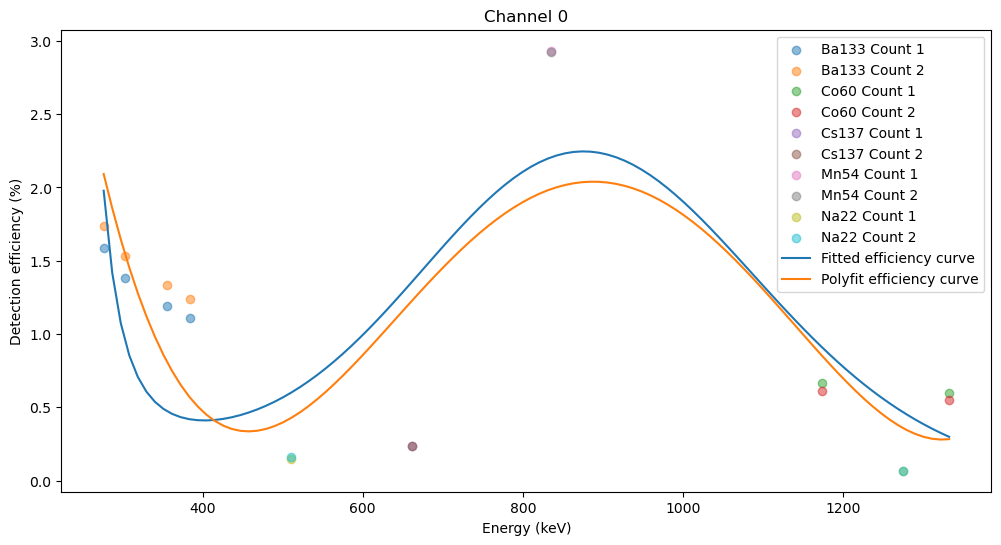

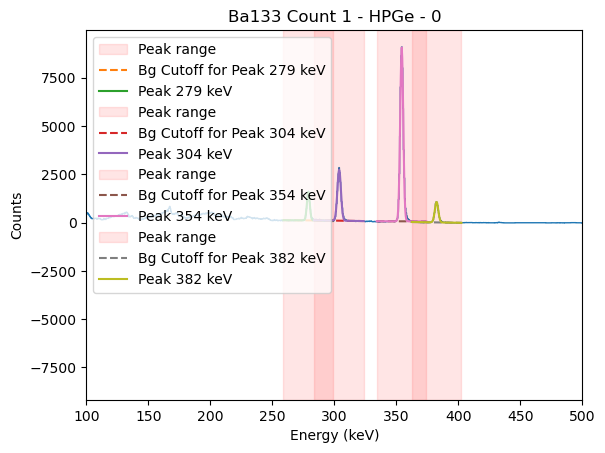

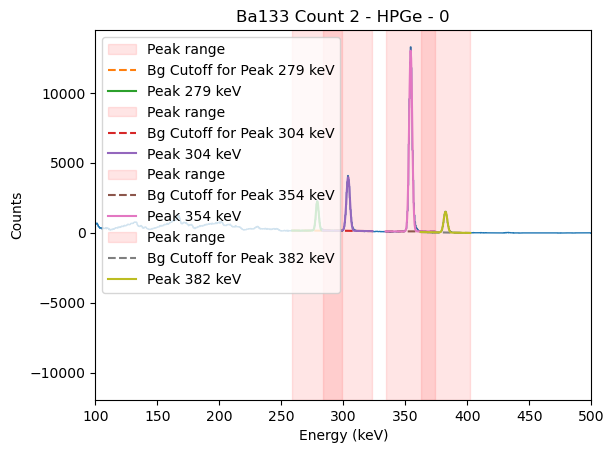

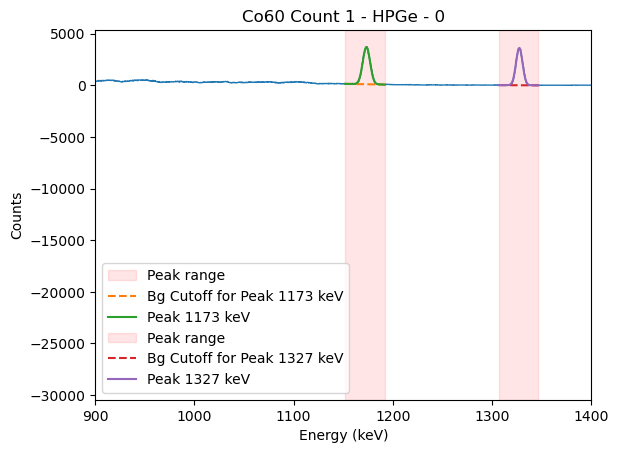

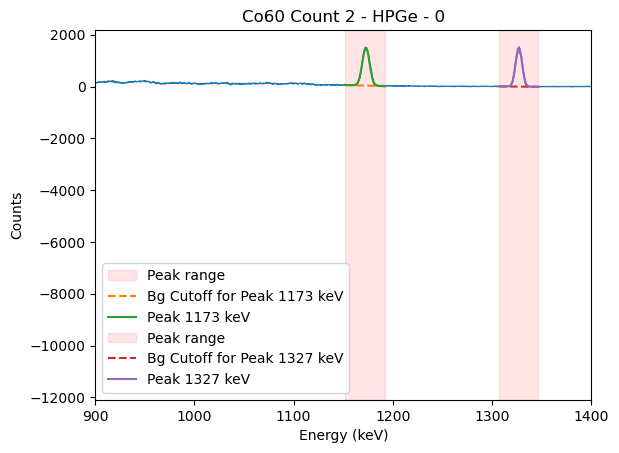

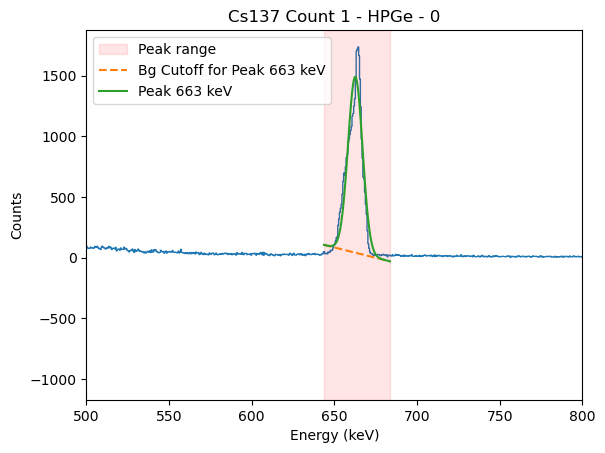

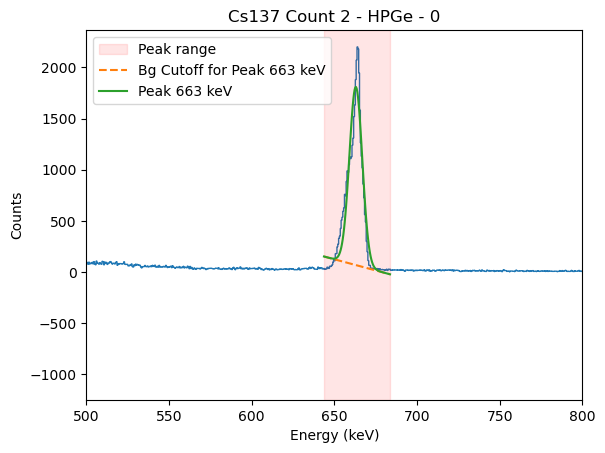

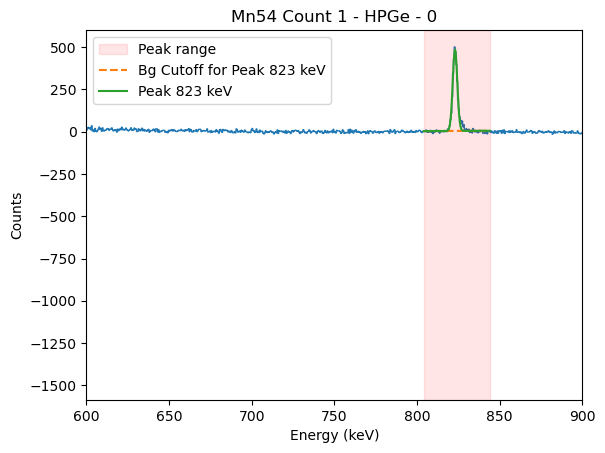

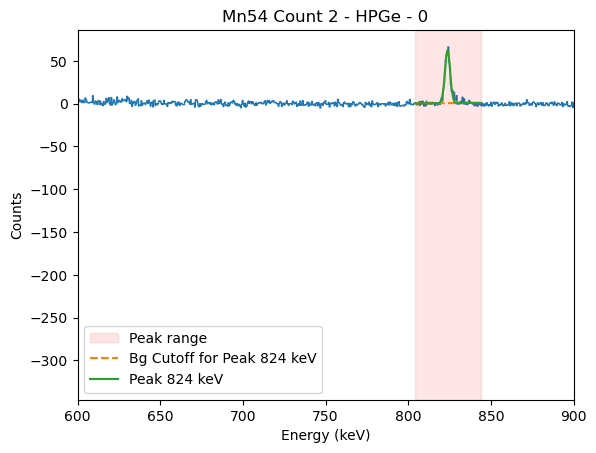

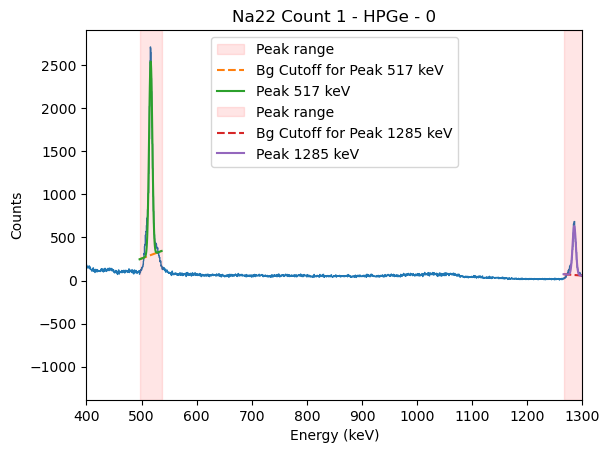

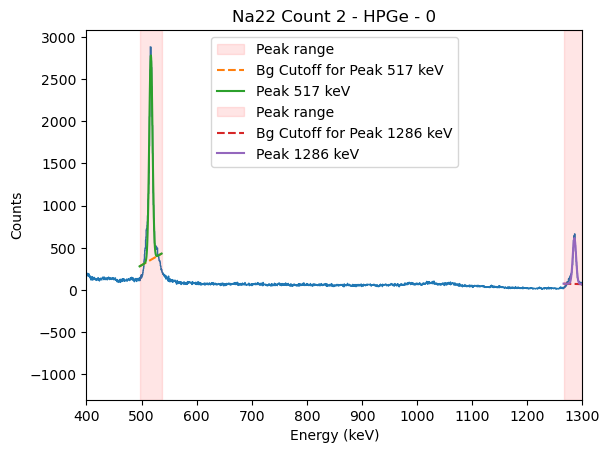

In [ ]:
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

channels = []
efficiency_coeffs = {}
measurement = list(check_source_measurements.values())[0]

# search_widths = np.arange(20, 50, 2)
# for search_width in search_widths:
search_width = 20
threshold_overlap = 10
for detector in measurement.detectors:
    channels.append(detector.channel_nb)

xlim_dict = {
    'Ba133': [100, 500],
    'Co60': [900, 1400],
    'Cs137': [500, 800],
    'Mn54': [600, 900],
    'Na22': [400, 1300],
}

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 6))

background_detector = background_meas.get_detector(channel_nb)
energies = []
efficiencies = []
for name, measurement in check_source_measurements.items():
    check_source_detector = measurement.get_detector(channel_nb)
    hist, bin_edges = check_source_detector.get_energy_hist_background_substract(background_detector, bins=None)
    calibrated_bin_edges = np.polyval(calibration_coeffs[channel_nb], bin_edges)

    # plot the histogram
    fig2,ax2 = plt.subplots()
    ax2.stairs(hist, calibrated_bin_edges)
    # ax2.set_xlim(left=0, right=500)

    # See how well calibrated peaks match expected energies
    expected_energies = measurement.check_source.nuclide.energy
    for energy in expected_energies:
        lower_ind = np.argmin(np.abs((energy - search_width) - calibrated_bin_edges))
        upper_ind = np.argmin(np.abs((energy + search_width) - calibrated_bin_edges))
        hist_search = hist[lower_ind:upper_ind]

        peaks, peak_params = find_peaks(hist_search, height=np.max(hist_search) * 0.5)

    # print('notebook search_width:', search_width, ' threshold_overlap:', threshold_overlap)

    uncalibrated = np.array(
                measurement.check_source.nuclide._uncalibrated_measured_energies.get(channel_nb, []),
                dtype=float
            )
    calibrated_ergs = np.polyval(calibration_coeffs[channel_nb], uncalibrated)


    ax2.set_xlabel("Energy (keV)")
    ax2.set_ylabel("Counts")
    ax2.set_title(f"{measurement.name} - {measurement.detector_type} - {channel_nb}")
    ax2.legend()
    nuclide = name.split()[0]
    if nuclide in xlim_dict:
        ax2.set_xlim(left=xlim_dict[nuclide][0], right=xlim_dict[nuclide][1])
    else:
        ax2.set_xlim(left=0, right=1500)
    
    efficiency = measurement.compute_detection_efficiency(
        background_measurement=background_meas,
        calibration_coeffs=calibration_coeffs[channel_nb],
        channel_nb=channel_nb,
        search_width=search_width,
        threshold_overlap=threshold_overlap,
        # summing_method='sum_gaussian',
        summing_method='sum_histogram'
    )
    print("\n" + "=" * 40)

    energies += measurement.check_source.nuclide.energy
    efficiencies += list(efficiency)
    ax.scatter(
        measurement.check_source.nuclide.energy,
        efficiency * 100,
        label=name,
        alpha=0.5
    )

# Sort energies and efficiencies for fitting
sorted_indices = np.argsort(energies)
energies = np.array(energies)[sorted_indices]
efficiencies = np.array(efficiencies)[sorted_indices]
print(f"Ch {channel_nb} \n\t Energies: {energies}, \n\t Efficiencies: {efficiencies}")

# Fit the efficiency curve
popt, pcov = curve_fit(
    eff_curve_func,
    energies,
    efficiencies,
    p0=[-1, 1, 0, 0],
)

poly_coeff = np.polyfit(energies, efficiencies, 4)
efficiency_coeffs[channel_nb] = poly_coeff
xs = np.linspace(
    energies[0],
    energies[-1],
    100,
)
ax.plot(
    xs,
    eff_curve_func(xs, *popt) * 100,
    label="Fitted efficiency curve",
)

ax.plot(
    xs,
    np.polyval(poly_coeff, xs) * 100,
    label="Polyfit efficiency curve",
)
ax.set_xlabel("Energy (keV)")
ax.set_ylabel("Detection efficiency (%)")
ax.set_title(f"Channel {channel_nb}")
ax.legend()
# plt.ylim(bottom=0)
print(popt)
plt.show()

## Calculating average neutron rate from activation foils

First, the irradiation schedule and the foil information is collected.

In [ ]:
all_neutron_rates = []
all_neutron_rates_err = []

In [ ]:
from process_foil_data import irradiations, time_generator_off

### Niobium Packet #3 Results

The activity of Nb-92m is measured using its 934 keV gamma peak and used to determine the neutron rate during the irradiation. Nb-92m is formed from the Nb-93(n,2n) reaction, which has a threshold energy of 8.9 MeV. 

The gamma spectrum obtained from the various measurements of the Niobium Packet #3 after irradiation are used to calculate the neutron rate of the overall irradiation. 

In [ ]:
print(foil_measurements["Nb Packet #6"])

In [ ]:
from process_foil_data import calculate_neutron_rate_from_foil

foil_name = "Nb Packet #6"

neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
                                                                    foil_name,
                                                                    background_meas,
                                                                    calibration_coeffs,
                                                                    efficiency_coeffs,
                                                                    search_width=15)

for count_name in neutron_rates.keys():
    print(count_name)
    for ch in np.sort(list(neutron_rates[count_name].keys())):
        neutron_rate = neutron_rates[count_name][ch]
        neutron_rate_err = neutron_rate_errs[count_name][ch]
        print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
        all_neutron_rates.append(neutron_rate[0])
        all_neutron_rates_err.append(neutron_rate_err[0])


### Zirconium Packet #1 Results

The activity of Zr-89 is measured using its 909 keV gamma peak and used to determine the neutron rate during the irradiation. Zr-89 m is formed from the Zr-90(n,2n) reaction, which has a threshold energy of 12.1 MeV. 

The gamma spectrum obtained from the various measurements of the Zirconium Packet #1 after irradiation are used to calculate the neutron rate of the overall irradiation. 

In [ ]:
foil_name = "Zr Packet #1"

neutron_rates, neutron_rate_errs = calculate_neutron_rate_from_foil(foil_measurements,
                                                                    foil_name,
                                                                    background_meas,
                                                                    calibration_coeffs,
                                                                    efficiency_coeffs,
                                                                    search_width=15)

for count_name in neutron_rates.keys():
    print(count_name)
    for ch in np.sort(list(neutron_rates[count_name].keys())):
        neutron_rate = neutron_rates[count_name][ch]
        neutron_rate_err = neutron_rate_errs[count_name][ch]
        print(f"\t Ch {ch}: Neutron rate: {neutron_rate[0]:.3e} +/- {neutron_rate_err[0]:.3e} n/s")
        all_neutron_rates.append(neutron_rate[0])
        all_neutron_rates_err.append(neutron_rate_err[0])

### Averaging foil results

The average of the neutron rates of the Niobium and Zirconium foil packets is calculated and added to the processed_data.json file. 

In [ ]:
average_neutron_rate = np.mean(all_neutron_rates)
# average_neutron_rate_err = np.sqrt(np.sum(np.array(all_neutron_rates_err) ** 2)) / len(all_neutron_rates_err)
average_neutron_rate_err = np.std(all_neutron_rates, ddof=1)  # Use ddof=1 for sample standard deviation

print(f"Average neutron rate: {average_neutron_rate:.3e} ± {average_neutron_rate_err:.3e} n/s")

In [ ]:
processed_data_file = "../../data/processed_data.json"

processed_data = {
    "neutron_rate_used_in_model": {
        "value":average_neutron_rate,
        "error": average_neutron_rate_err,
        "unit": "neutron / second"
    }
}

try:
    with open(processed_data_file, "r") as f:
        existing_data = json.load(f)
except FileNotFoundError:
    print(f"Processed data file not found, creating it in {processed_data_file}")
    existing_data = {}

existing_data.update(processed_data)

with open(processed_data_file, "w") as f:
    json.dump(existing_data, f, indent=4)

print(f"Processed data stored in {processed_data_file}")